In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# # from vcme.utils import yeast_data, YeastMetadata
# output_device = 'cuda:0'

# fig_path = 'figures/'
# result_path = 'results/'

# wd = '/blue/juannanzhou/juannanzhou/vcme_project/'
# checkpoint_path = wd + 'model_checkpoints/37C_r2_threshold=None_MAF_threshold=0/'

# geno_path = "/orange/juannanzhou/MarginalEpistasis/data/"
# pheno_path = "/orange/juannanzhou/dryad_data/"
# pheno_name = '37C'
# model_name = 'GP_model_k=8.model'

# data = yeast_data(geno_path, pheno_path, pheno_name, output_device, prune_snps=False, r2_threshold=None, maf_threshold=0, top_percent=25)

# snp_info_path = wd + "data/yeast/snp_info_final.csv"
# pathway_info_path = wd + "data/yeast/all_pathway_gene_tables.tsv"

# genomic_meta_data = YeastMetadata(snp_info_path, pathway_info_path)
# snp_info = genomic_meta_data.snp_info
# gene_info = genomic_meta_data.gene_info
# gene_info = gene_info.set_index('gene_standard_name')

# pathway_genes = genomic_meta_data.pathway_genes

In [24]:
fig_path = 'figures/'
results = pd.read_csv("results/pathway_results_q_values_n=500.csv", index_col=0)
results = results[['description', 'mean_percent_SS', 'p_value', 'additive_mean', 'additive_sum_p_value', 'additive_mean_p_value']]

# plt.scatter(results.additive_mean, results.mean_percent_SS)

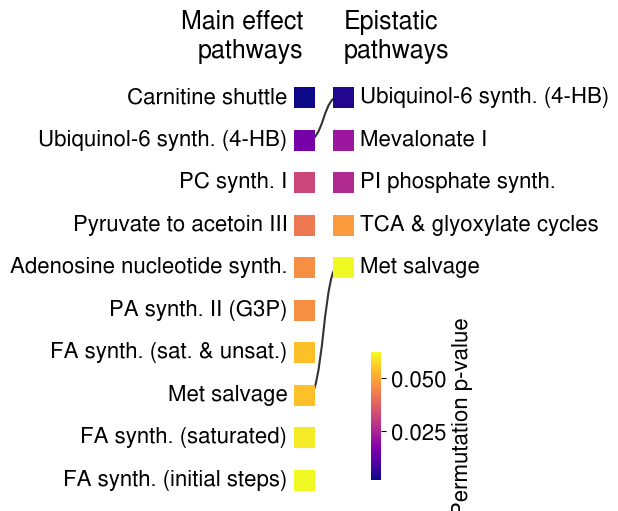

In [27]:
top_n = 10
pathway_p_values_epistatic = results.sort_values(by='p_value')[:5].p_value
pathway_p_values_additive = results.sort_values(by='additive_sum_p_value')[:10].additive_sum_p_value

import importlib
import yeast_analysis.pathway_plots
importlib.reload(yeast_analysis.pathway_plots)

from yeast_analysis.pathway_plots import plot_rank_overlap
from yeast_analysis.pathway_shorthands import pathway_shorthands


plt.rcParams.update({
    "font.size": 24,
    "font.family": "nimbus sans"
})

fig, ax = plot_rank_overlap(
    pathway_p_values_epistatic,     
    pathway_p_values_additive,     
    label_map=pathway_shorthands,
    column_gap=0.1,
    figsize=(6, 5.),
    label_fontsize=16,
    header_fontsize=18,
    line_color='black',
    cmap="plasma",
    colorbar_label="Permutation p-value",
    curvature=1,
)

fig.savefig(fig_path + 'pathway_compare.pdf', bbox_inches='tight')